# 02 Baseline Validation (Rectangular Benchmark)

This notebook finalizes the rectangular case as a validation benchmark.

It compares dataset energies from the Kwant solver against:
- exact discrete rectangular tight-binding levels,
- a low-energy continuum approximation.

This is a consistency check, not a novelty claim.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.baseline import continuum_box_levels, exact_rectangular_tb_levels

In [2]:
data_path = PROJECT_ROOT / "data" / "rectangular_dataset_8_20.npz"
data = np.load(data_path)

nx = data["Lx"].astype(int)
ny = data["Ly"].astype(int)
kwant_levels = np.column_stack([data["E0"], data["E1"], data["E2"], data["E3"]])

exact_levels = np.array([exact_rectangular_tb_levels(int(ix), int(iy), num_levels=4, t=1.0) for ix, iy in zip(nx, ny)])
continuum_levels = np.array([continuum_box_levels(int(ix), int(iy), num_levels=4, t=1.0) for ix, iy in zip(nx, ny)])

err_exact = kwant_levels - exact_levels
err_cont = kwant_levels - continuum_levels

abs_err_exact = np.abs(err_exact)
print(f"Loaded: {data_path}")
print(f"Samples: {len(nx)}")
print(f"Overall max |E_kwant - E_exact_tb| across E0..E3: {abs_err_exact.max():.6e}")
for i in range(4):
    print(f"  Level E{i}: max abs error = {abs_err_exact[:, i].max():.6e}")

Loaded: D:\Diplom Physcis ML\Diplom Physcis ML\data\rectangular_dataset_8_20.npz
Samples: 169
Overall max |E_kwant - E_exact_tb| across E0..E3: 6.883383e-14
  Level E0: max abs error = 3.685940e-14
  Level E1: max abs error = 5.373479e-14
  Level E2: max abs error = 6.084022e-14
  Level E3: max abs error = 6.883383e-14


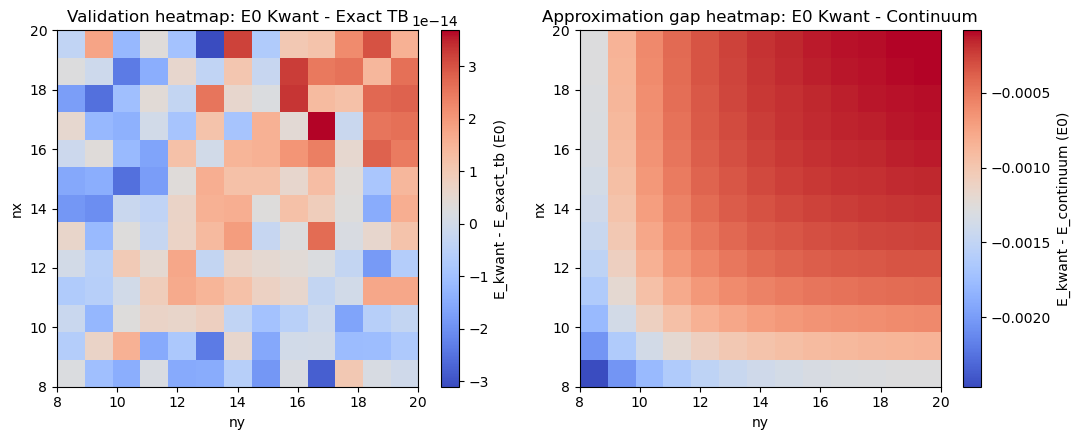

In [3]:
# Build regular 2D grids for heatmaps (x-axis: ny, y-axis: nx).
nx_unique = np.unique(nx)
ny_unique = np.unique(ny)
n_nx = len(nx_unique)
n_ny = len(ny_unique)

if len(nx) != n_nx * n_ny:
    raise ValueError("Dataset is not a full regular grid.")

# Dataset ordering is generated with nx outer loop and ny inner loop.
err_exact_e0_grid = err_exact[:, 0].reshape(n_nx, n_ny)
err_cont_e0_grid = err_cont[:, 0].reshape(n_nx, n_ny)

extent = [ny_unique.min(), ny_unique.max(), nx_unique.min(), nx_unique.max()]

plt.figure(figsize=(11, 4.5))

plt.subplot(1, 2, 1)
im0 = plt.imshow(err_exact_e0_grid, origin="lower", extent=extent, aspect="auto", cmap="coolwarm")
plt.colorbar(im0, label="E_kwant - E_exact_tb (E0)")
plt.xlabel("ny")
plt.ylabel("nx")
plt.title("Validation heatmap: E0 Kwant - Exact TB")

plt.subplot(1, 2, 2)
im1 = plt.imshow(err_cont_e0_grid, origin="lower", extent=extent, aspect="auto", cmap="coolwarm")
plt.colorbar(im1, label="E_kwant - E_continuum (E0)")
plt.xlabel("ny")
plt.ylabel("nx")
plt.title("Approximation gap heatmap: E0 Kwant - Continuum")

plt.tight_layout()
plt.show()